# Pipeline step 01 — Localizer GLM (hMT+)

**Purpose:** functionally localise left/right hMT+ per subject using the contrast
`movingPlaid − staticPlaid` (Bonferroni p = 0.05, cluster k = 50), then build the
group hMT+ mask used by later steps.

**Manuscript outputs:** Figure 2 (per-subject maps, exported to
`results/Figure2_localizer_hMT_persubject.png` and `results/localizer_plot-z_*`)
and Figure S3 (group activation map).

**High-pass:** 0.03 Hz (localizer-specific; the main-task steps use 0.003 Hz).

# GLM analysis on the localizer data [sim01]
It uses nilearn and performs the following steps:
1. Load the data from fmriPrep in BIDS format
2. Iterate on the subjects to:
   1. Select the predictors and confounds for the design matrix
   2. Generate 1st level model
   3. Estimate contrast maps
3. Generate group level maps
4. Generate hMT+ mask

In [1]:
# Imports
import os
import glob
from nilearn.glm.first_level import first_level_from_bids
from nilearn.interfaces.bids import save_glm_to_bids
from nilearn.glm import threshold_stats_img
from nilearn import plotting
from nilearn.plotting.cm import _cmap_d as nilearn_cmaps
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from nilearn.glm.second_level import SecondLevelModel
from nilearn.reporting import get_clusters_table
from nilearn.image import math_img, threshold_img
from nilearn.masking import apply_mask

In [2]:
# Settings
data_dir = '/DATAPOOL/VPMB/BIDS-VPMB-SPE'
space_label = "MNI152NLin2009cAsym"
derivatives_folder = "derivatives/fmriprep23/fmriprep"
nilearn_folder = os.path.join(data_dir,"derivatives","nilearn_glm")
task_label = "loc"
smoothing_fwhm = 6.0
high_pass_hz = 0.03

In [3]:
# Multiple comparison correction method for single subject level
mcc_method = "fdr"
mcc_param = 0.05
cluster_thres = 50

## 1. Load the data from fmriPrep in BIDS format

In [4]:
# import first level data automatically from fmriPrep derivatives
(
    models,
    models_run_imgs,
    models_events,
    models_confounds,
) = first_level_from_bids(
    data_dir,
    task_label,
    space_label,
    hrf_model="spm",
    noise_model="ar2",
    smoothing_fwhm=smoothing_fwhm,
    high_pass=high_pass_hz,
    slice_time_ref=None,
    n_jobs=12,
    derivatives_folder=derivatives_folder,
)

In [3]:
# Contrast list
contrast_list = [
    'MovingPlaid - StaticPlaid',
    'StaticPlaid - Fixation',
]
contrast_list_valid = [
    'movingPlaidMinusStaticPlaid',
    'staticPlaidMinusFixation',
]  

## 2. Iterate on the subjects

In [8]:
#for idx in range(len(models)):
from joblib import Parallel, delayed

# Define function for first level analysis
def f(idx):

    # fetch model
    model, imgs, events, confounds = (
        models[idx],
        models_run_imgs[idx],
        models_events[idx],
        models_confounds[idx],
    )

    subject = f"sub-{model.subject_label}"

    print(f"Executing GLM for subject: {subject}")

    # trim confounds
    confounds = confounds[0][['csf','csf_derivative1','csf_power2','csf_derivative1_power2',
                                'trans_x', 'trans_x_derivative1', 'trans_x_power2', 'trans_x_derivative1_power2',
                                'trans_y', 'trans_y_derivative1', 'trans_y_power2', 'trans_y_derivative1_power2',
                                'trans_z', 'trans_z_derivative1', 'trans_z_power2', 'trans_z_derivative1_power2',
                                'rot_x', 'rot_x_derivative1', 'rot_x_power2', 'rot_x_derivative1_power2',
                                'rot_y', 'rot_y_derivative1', 'rot_y_power2', 'rot_y_derivative1_power2',
                                'rot_z', 'rot_z_derivative1', 'rot_z_power2', 'rot_z_derivative1_power2',
                                ]]

    # replace NaNs with 0s in confounds
    confounds = confounds.fillna(0)
    
    # Fit and contrasts
    model.fit(imgs, events, confounds)

    for ii in range(len(contrast_list)):

        z_map = model.compute_contrast(contrast_list[ii], output_type="z_score")
        t_map = model.compute_contrast(contrast_list[ii], output_type="stat")
        beta_map = model.compute_contrast(contrast_list[ii], output_type="effect_size")

        # save maps to disk
        z_map.to_filename(os.path.join(nilearn_folder,
                                        f"{subject}_task-{task_label}_stat-z_con-{contrast_list_valid[ii]}.nii.gz"))
        t_map.to_filename(os.path.join(nilearn_folder,
                                        f"{subject}_task-{task_label}_stat-t_con-{contrast_list_valid[ii]}.nii.gz"))
        beta_map.to_filename(os.path.join(nilearn_folder,
                                        f"{subject}_task-{task_label}_stat-beta_con-{contrast_list_valid[ii]}.nii.gz"))

        # Threshold z_map and apply mask to t_map and beta_map
        clean_map, threshold = threshold_stats_img(
            z_map, alpha=mcc_param, height_control=mcc_method, cluster_threshold=cluster_thres
        )

        mask = math_img("img > 0", img=clean_map)
        t_map_thresholded = threshold_img(t_map, threshold = 0, mask_img = mask)
        beta_map_thresholded = threshold_img(beta_map, threshold = 0, mask_img = mask)

        # save thresholded maps to disk
        clean_map.to_filename(os.path.join(nilearn_folder,
                                            f"{subject}_task-{task_label}_stat-z_con-{contrast_list_valid[ii]}_c-{mcc_method}_p-{mcc_param}_clusterk-{cluster_thres}.nii.gz"))                                                      
        t_map_thresholded.to_filename(os.path.join(nilearn_folder,
                                        f"{subject}_task-{task_label}_stat-t_con-{contrast_list_valid[ii]}_c-{mcc_method}_p-{mcc_param}_clusterk-{cluster_thres}.nii.gz"))
        beta_map_thresholded.to_filename(os.path.join(nilearn_folder,
                                            f"{subject}_task-{task_label}_stat-beta_con-{contrast_list_valid[ii]}_c-{mcc_method}_p-{mcc_param}_clusterk-{cluster_thres}.nii.gz"))                                           

        # create figure with thresholded map for fun
        plotting.plot_glass_brain(
            clean_map,
            colorbar=True,
            threshold=threshold,
            plot_abs=False,
            display_mode="ortho",
            figure=plt.figure(figsize=(10, 4)),
        )

        plt.savefig(os.path.join(
            nilearn_folder,
            f"{subject}_task-{task_label}_plot-z_con-{contrast_list_valid[ii]}_cc-{mcc_method}_p-{mcc_param}_clusterk-{cluster_thres}.png"
            )
        )

        # Export cluster table
        table = get_clusters_table(z_map, threshold, cluster_thres)
        table.to_csv(os.path.join(nilearn_folder,
                                f"{subject}_task-{task_label}_table-clusters_con-{contrast_list_valid[ii]}_c-{mcc_method}_p-{mcc_param}_clusterk-{cluster_thres}.tsv"),sep='\t')
    
    # Memory...
    del model, imgs, events, confounds

# Run in parallel
Parallel(n_jobs=15)(delayed(f)(idx) for idx in range(len(models)))    

Executing GLM for subject: sub-16
Executing GLM for subject: sub-11
Executing GLM for subject: sub-23
Executing GLM for subject: sub-21
Executing GLM for subject: sub-12
Executing GLM for subject: sub-06
Executing GLM for subject: sub-10
Executing GLM for subject: sub-05
Executing GLM for subject: sub-15
Executing GLM for subject: sub-02
Executing GLM for subject: sub-08
Executing GLM for subject: sub-03
Executing GLM for subject: sub-07
Executing GLM for subject: sub-22
Executing GLM for subject: sub-01


/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/glm/_utils.py:321: UserWarning: Matrix is singular at working precision, regularizing...
  warn("Matrix is singular at working precision, regularizing...")
/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/glm/_utils.py:321: UserWarning: Matrix is singular at working precision, regularizing...
  warn("Matrix is singular at working precision, regularizing...")
/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/glm/_utils.py:321: UserWarning: Matrix is singular at working precision, regularizing...
  warn("Matrix is singular at working precision, regularizing...")
/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/glm/_utils.py:321: UserWarning: Matrix is singular at working precision, regularizing...
  warn("Matrix is singular at working precision, regularizing...")
/DATAPOOL/home/a

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

## 3. Group level analysis

In [8]:
# to mount this folder on ubuntu, type: sshfs 192.168.0.68:/DATAPOOL ~/mnt/DATAPOOL
#data_dir = '/home/alexandresayal/mnt/DATAPOOL/VPMB/BIDS-VPMB-SPE'
# import os
# import glob
# import matplotlib.pyplot as plt
# import pandas as pd
# import numpy as np# Multiple comparison correction method for group

In [4]:
mcc_method_g = "bonferroni"
mcc_param_s_g = 'p' # q or p
mcc_param_g = 0.05
cluster_thres_g = 50

In [5]:
# contrast index
c_idx = 0

# Contrast list (just to be sure)
contrast_list = [
    'MovingPlaid - StaticPlaid',
    'StaticPlaid - Fixation',
]
contrast_list_valid = [
    'movingPlaidMinusStaticPlaid',
    'staticPlaidMinusFixation',
]  

In [6]:
# List all zmap nii.gz files (uncorrected)
zmap_files = glob.glob(
    os.path.join(nilearn_folder,
        f"sub-*_task-loc_stat-z_con-{contrast_list_valid[c_idx]}.nii.gz"
    )
)
zmap_files.sort()

subject_list = [os.path.basename(f).split('_')[0] for f in zmap_files]
subject_list

['sub-01',
 'sub-02',
 'sub-03',
 'sub-05',
 'sub-06',
 'sub-07',
 'sub-08',
 'sub-10',
 'sub-11',
 'sub-12',
 'sub-15',
 'sub-16',
 'sub-21',
 'sub-22',
 'sub-23']

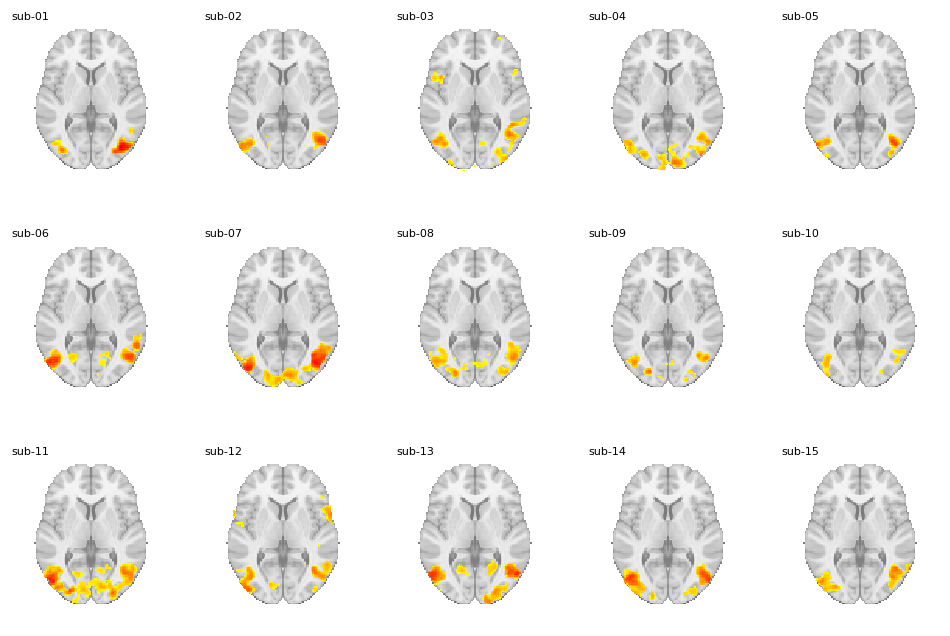

In [44]:
#| label: loc_singlesubject
# Plot all subjects
#subjects = data["ext_vars"]["participant_id"].tolist()

fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(12, 8))
for cidx, zmap in enumerate(zmap_files):

    clean_map, threshold = threshold_stats_img(
        zmap, alpha=mcc_param_g, height_control=mcc_method_g, cluster_threshold=cluster_thres_g
    )

    P = plotting.plot_stat_map(
        clean_map,
        colorbar=False,
        cmap=nilearn_cmaps["black_red_r"],
        threshold=threshold,
        vmin=0,
        vmax=20,
        axes=axes.flatten()[cidx],
        display_mode="z",
        cut_coords=[4],
        annotate=False,
        symmetric_cbar=False,
    )

    P.title(f"sub-{cidx+1:02d}",size=8, color="black", bgcolor="white")

#fig.suptitle(f"Subject-level activation maps for contrast '{contrast_list[c_idx]}'\n({mcc_method_g}, {mcc_param_s_g}={mcc_param_g}, k>{cluster_thres_g})")
plt.show()

In [8]:
# export above figure as png and pdf
fig.savefig(os.path.join('..','results',
    f"localizer_plot-z_con-{contrast_list_valid[c_idx]}_c-{mcc_method_g}_p-{mcc_param_g}_clusterk-{cluster_thres_g}.png"
    )
)
fig.savefig(os.path.join('..','results',
    f"localizer_plot-z_con-{contrast_list_valid[c_idx]}_c-{mcc_method_g}_p-{mcc_param_g}_clusterk-{cluster_thres_g}.pdf"
    )
)

In [7]:
# create design matrix for 2nd level
second_level_input = zmap_files
design_matrix_g = pd.DataFrame(
    [1] * len(second_level_input),
    columns=["intercept"],
)

# define 2nd level model
second_level_model = SecondLevelModel(smoothing_fwhm=6.0, n_jobs=12)

second_level_model = second_level_model.fit(
    second_level_input,
    design_matrix=design_matrix_g,
)

# compute contrast (z score map)
z_map_g = second_level_model.compute_contrast(
    second_level_contrast="intercept",
    output_type="z_score",
)

# compute contrast (t score map)
t_map_g = second_level_model.compute_contrast(
    second_level_contrast="intercept",
    output_type="stat",
)

# compute contrast (beta map)
beta_map_g = second_level_model.compute_contrast(
    second_level_contrast="intercept",
    output_type='effect_size',
)

# Save z_map_g, t_map_g, beta_map_g
z_map_g.to_filename(os.path.join(nilearn_folder,"group",f"group_task-{task_label}_stat-z_con-{contrast_list_valid[c_idx]}.nii.gz"))
t_map_g.to_filename(os.path.join(nilearn_folder,"group",f"group_task-{task_label}_stat-t_con-{contrast_list_valid[c_idx]}.nii.gz"))
beta_map_g.to_filename(os.path.join(nilearn_folder,"group",f"group_task-{task_label}_stat-beta_con-{contrast_list_valid[c_idx]}.nii.gz"))

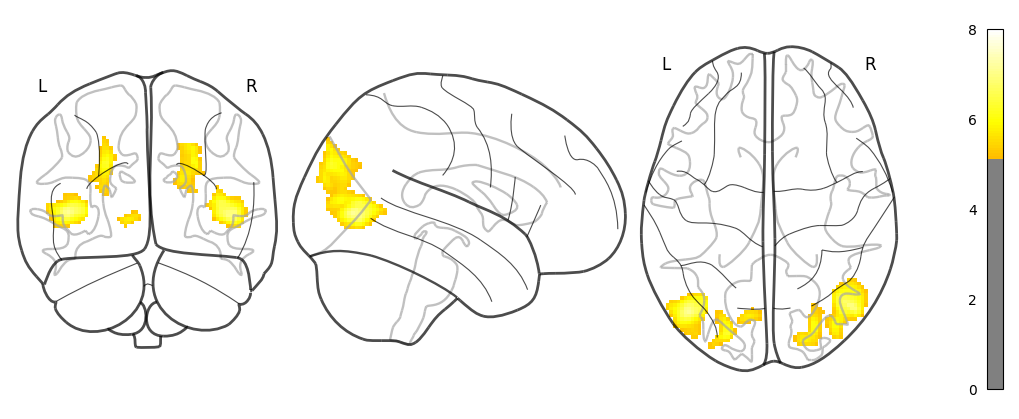

In [8]:
# Threshold zmap and plot it
clean_map_g, threshold_g = threshold_stats_img(
    z_map_g, alpha=mcc_param_g, height_control=mcc_method_g, cluster_threshold=cluster_thres_g
)

plotting.plot_glass_brain(
    clean_map_g,
    colorbar=True,
    threshold=threshold_g,
    plot_abs=False,
    display_mode="ortho",
    vmax=8,
    figure=plt.figure(figsize=(10, 4)),
    symmetric_cbar=False,
    cmap=nilearn_cmaps["cold_hot"],
)

plt.savefig(os.path.join(nilearn_folder,"group",
                         f"group_task-{task_label}_plot-z_con-{contrast_list_valid[c_idx]}_c-{mcc_method_g}_p-{mcc_param_g}_clusterk-{cluster_thres_g}.png"))

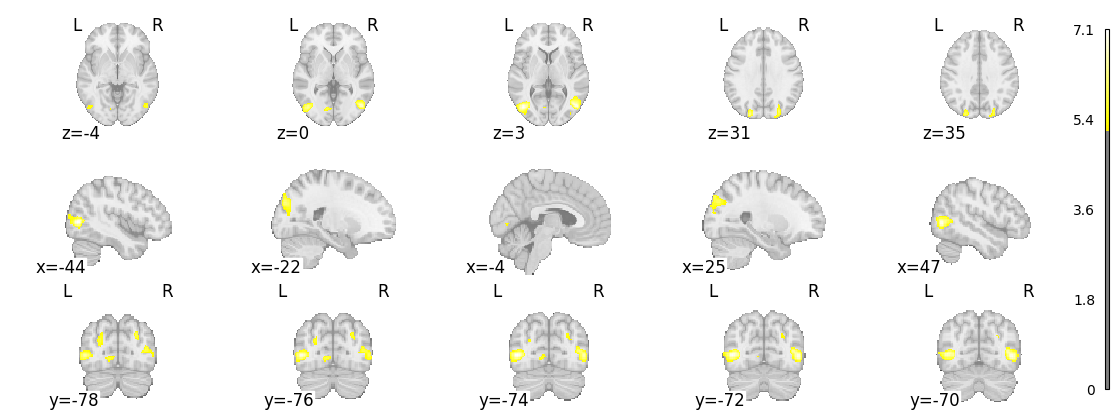

In [18]:
# plot in mosaic
plotting.plot_stat_map(
    clean_map_g,
    colorbar=True,
    threshold=threshold_g,
    symmetric_cbar=False,
    display_mode="mosaic",
    cut_coords=5,
    figure=plt.figure(figsize=(11, 4)),
)

In [11]:
# Export cluster table
table,cluster_map_g = get_clusters_table(z_map_g, threshold_g, cluster_thres_g,
                                return_label_maps=True)

table.to_csv(os.path.join(nilearn_folder,"group",
                          f"group_task-{task_label}_table-clusters_con-{contrast_list_valid[c_idx]}_c-{mcc_method_g}_p-{mcc_param_g}_clusterk-{cluster_thres_g}.tsv"),sep='\t')
#print(table)
#print(table.to_latex())
table


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3)
0,1,-44.5,-74.5,3.5,7.143912,4432
1,1a,-40.5,-86.5,9.5,5.465928,
2,2,47.5,-70.5,1.5,6.995054,5288
3,2a,39.5,-80.5,11.5,6.029977,
4,3,-22.5,-86.5,31.5,6.251474,2344
5,4,25.5,-82.5,31.5,6.041377,2504
6,4a,25.5,-86.5,39.5,5.904060,
7,4b,21.5,-90.5,23.5,5.820826,
8,5,-10.5,-76.5,-0.5,5.781139,400


In [24]:
# fetch X, Y, Z coordinates of the hMT lines of the table
hmt_coords = [(),()]
hmt_coords[0] = table[["X", "Y", "Z"]].iloc[0].tolist()
hmt_coords[1] = table[["X", "Y", "Z"]].iloc[2].tolist()
hmt_coords


[[-44.5, -74.5, 3.5], [47.5, -70.5, 1.5]]

/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.9/site-packages/numpy/core/fromnumeric.py:771: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



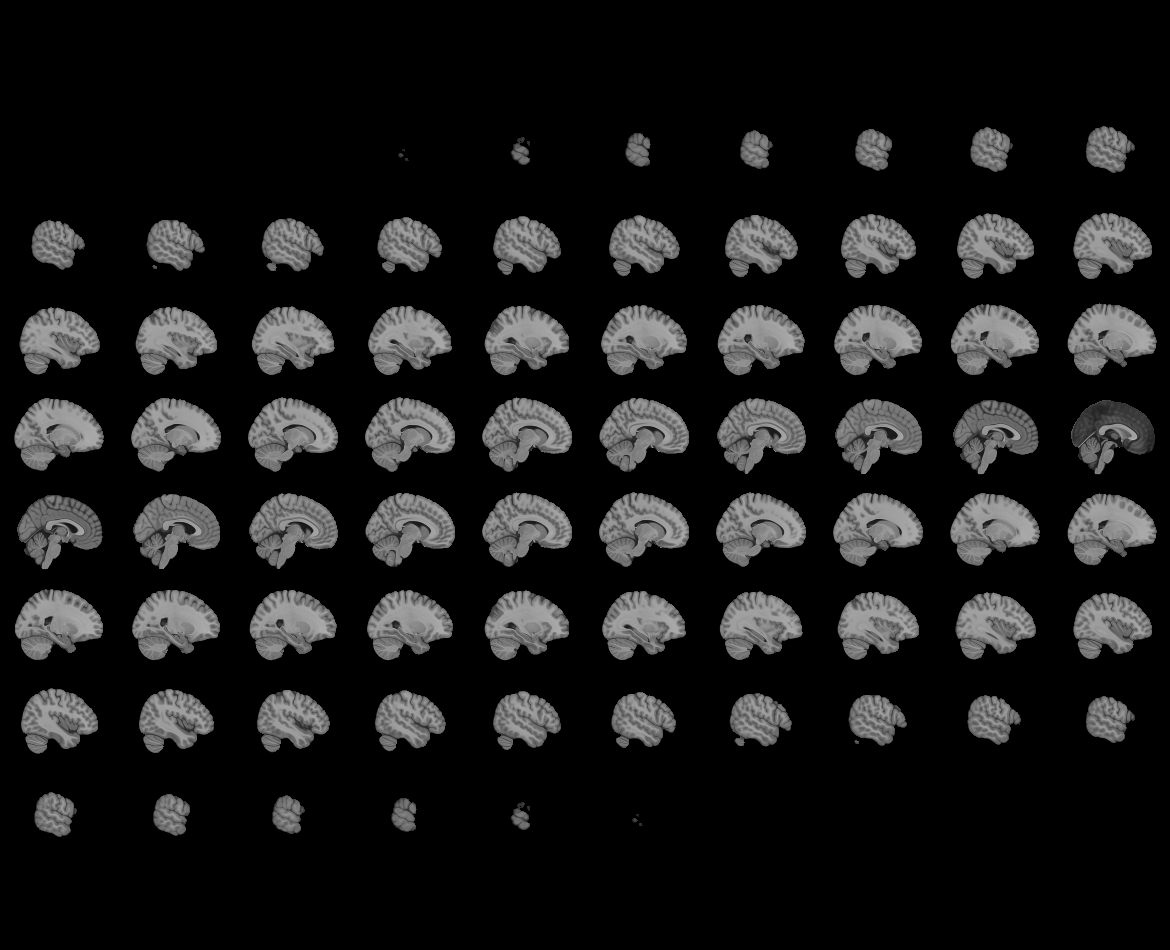
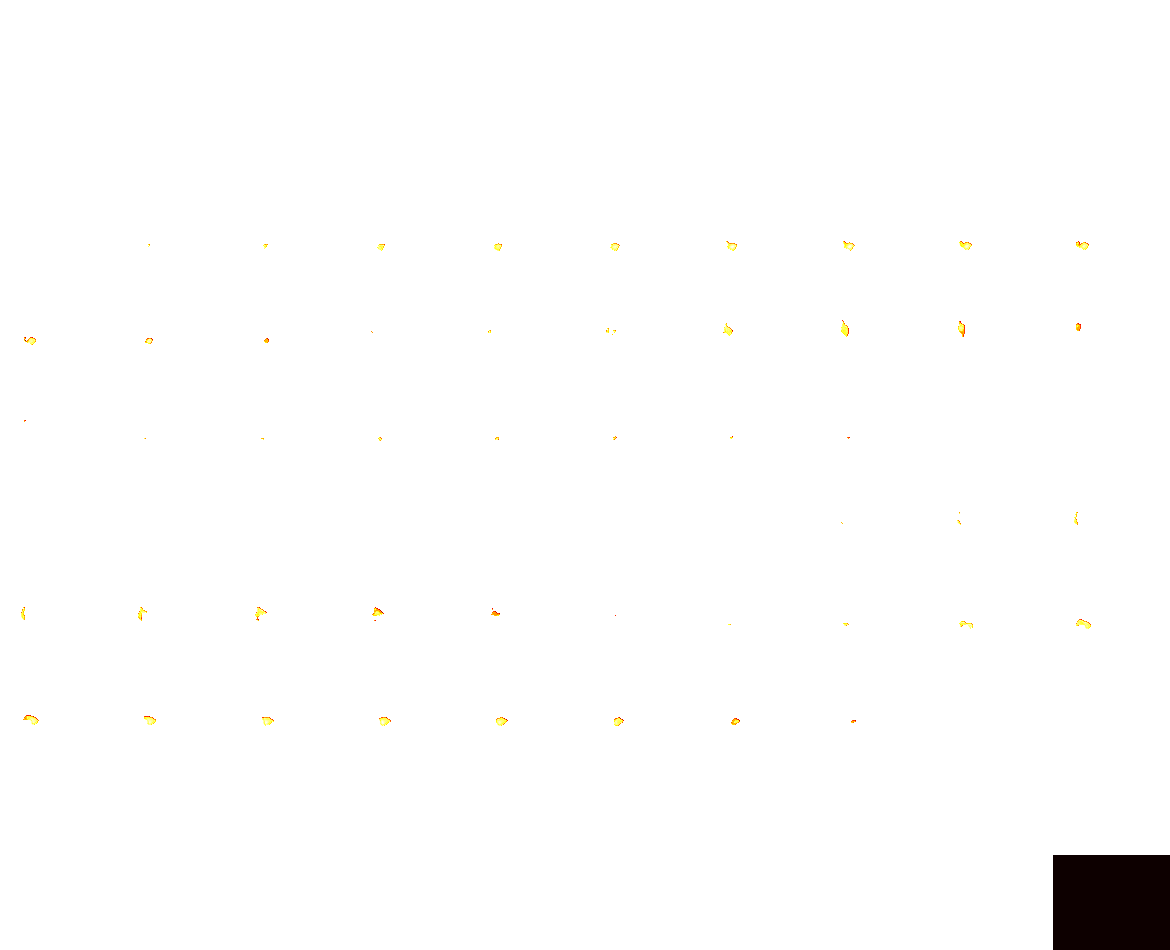

In [19]:
# View map interactively
plotting.view_img(clean_map_g,
         threshold=threshold_g
        )

# ROI analysis

/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/numpy/core/fromnumeric.py:771: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



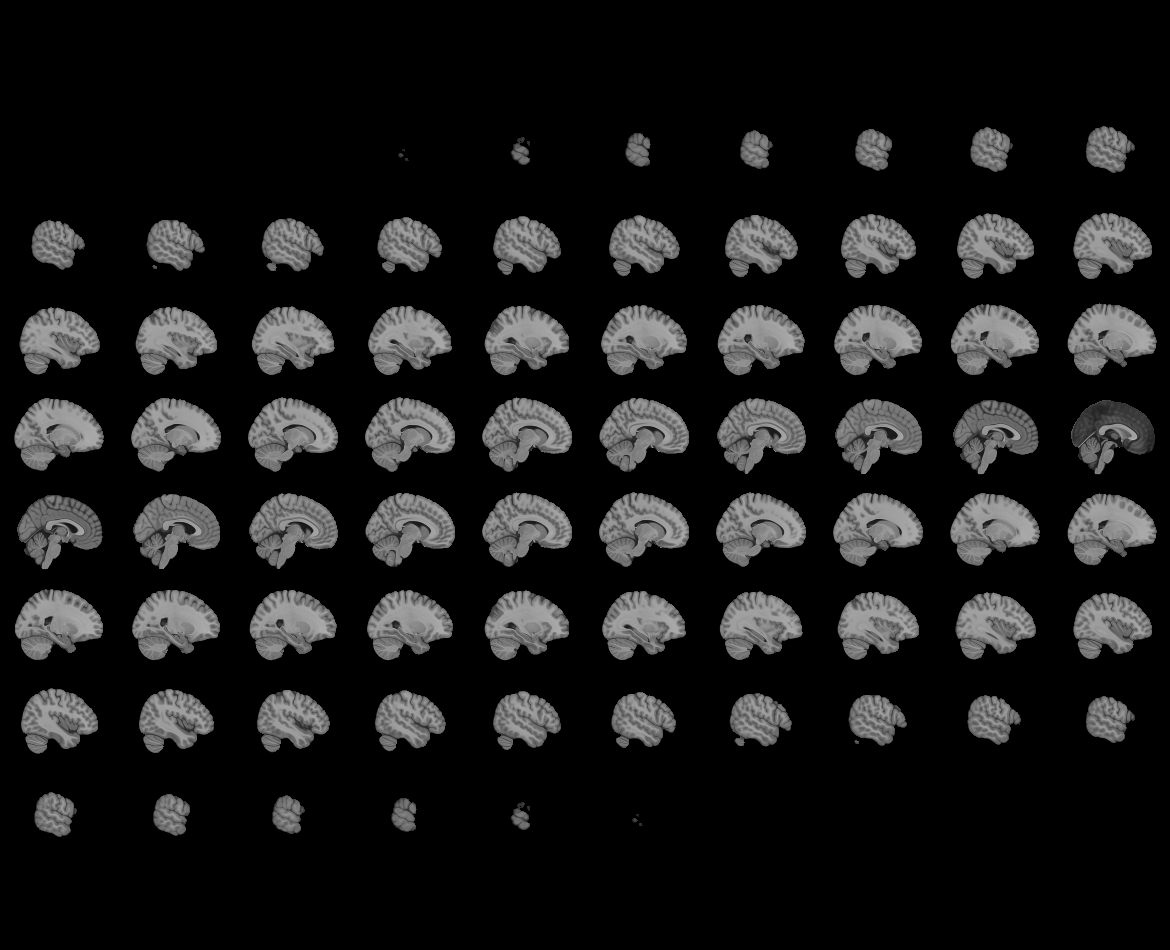
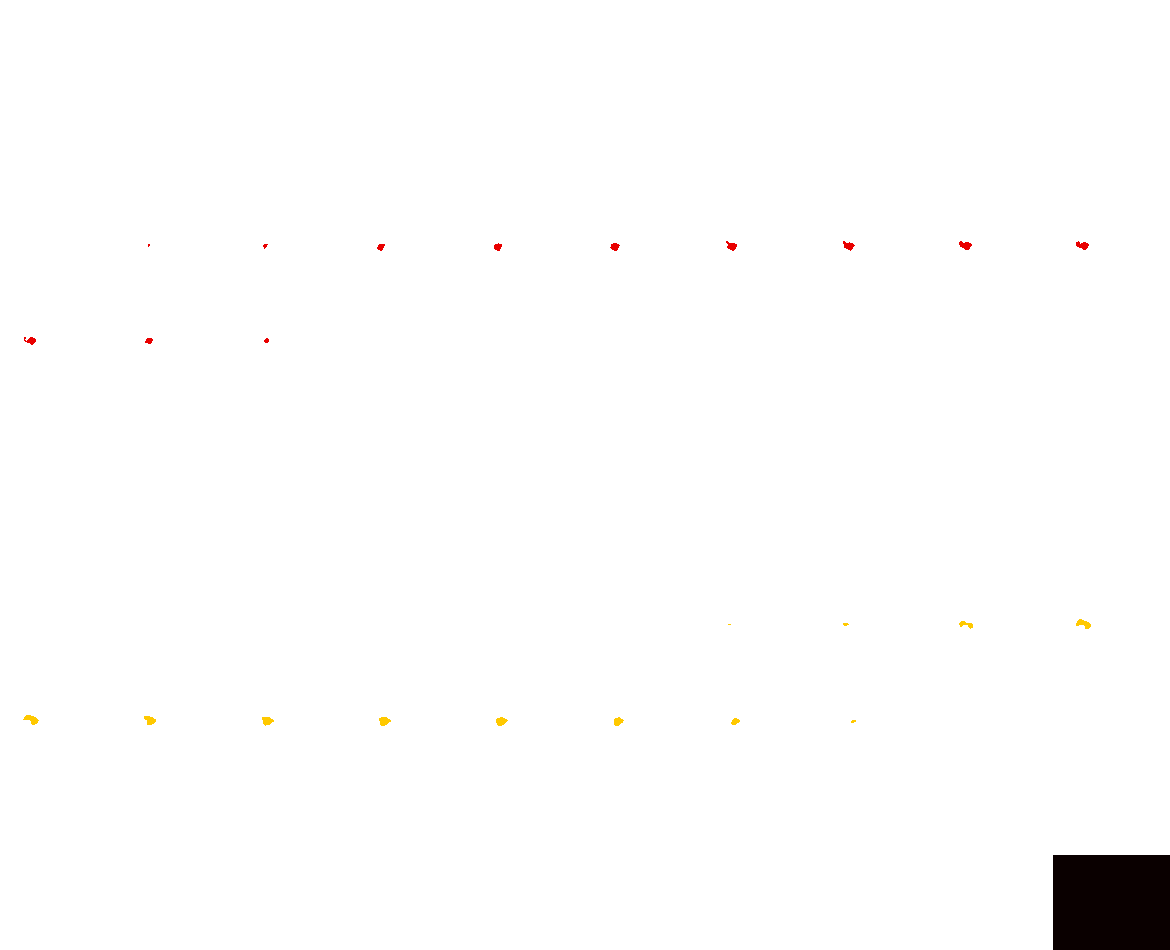

In [25]:
#| label: loc_group_interactive
# Show cluster_map_g
plotting.view_img(cluster_map_g[0],
                  vmax=3, vmin=0,
                  resampling_interpolation='nearest',
                  cmap='hot',
                  symmetric_cmap=False)

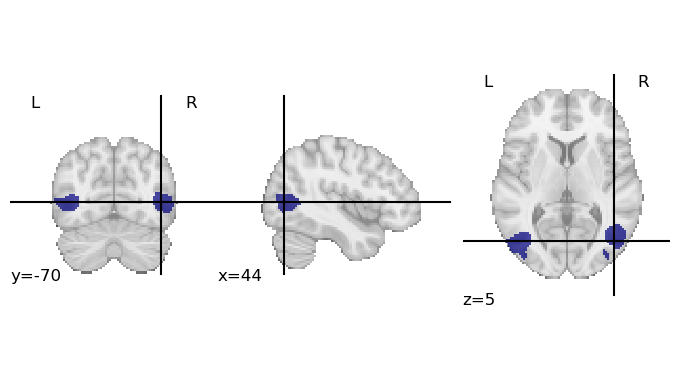

In [26]:
# Generate bilateral hMT+ mask
# in this case, it is values 1 and 2 from cluster_map_g
aux_mask1 = math_img('img == 1', img=cluster_map_g[0])
aux_mask2 = math_img('img == 2', img=cluster_map_g[0])
mask_hMT = math_img('img1 + img2', img1=aux_mask1, img2=aux_mask2)

plotting.plot_roi(mask_hMT)

# save mask
mask_hMT.to_filename(os.path.join(data_dir,"derivatives","nilearn_glm","group",'mask_hMT.nii.gz'))


In [27]:
# fetch map values inside mask_hMT  
# Apply mask to z_map_g
z_map_hMT = apply_mask(z_map_g, mask_hMT)

# Apply mask to beta_map_g
beta_map_hMT = apply_mask(beta_map_g, mask_hMT)

# Estimate mean of z_map_hMT
z_map_hMT_mean = np.mean(z_map_hMT)

z_map_hMT_mean

5.752466368767046